In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import jax.numpy as jnp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import apebench  # only for data generation

c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\trainax\_general_trainer.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


We'll model the Kolmogorov flow (a canonical fluid dynamics model driven by a steady, sinusoidal external force) using a PDE-Transformer architecture (specifically the separate channel version), as shown in [Holzschuh et al 2025](https://arxiv.org/abs/2505.24717). The goal is to predict how a given velocity or vorticity grid evolves with time. The groud truth is simulated with APEBench.

# Build model

We'll reproduce the PDE-Transformer architecture as explained in [Holzschuh et al 2025](https://arxiv.org/abs/2505.24717), specifically the separate channel version. The layers look like:
- MLP for conditioning (`ConditioningEncoder`)
- Tokenizer at input (`_extract_patches`,`patch_embed`)
- Transformer stages (`TransformerStage`<-`SwinTransformer`)
    - Layer Norm (`AdaLayerNorm`<-`ConditioningMLP`)
    - Scale, Shift (`tf.roll`)
    - Shifted Window MHSA (`WindowAttention`,`window_partition`,`window_reverse`)
    - Channel-wise MHSA (`ChannelAttention`,`compute_attn_mask`)
    - MLP (`AdaLayerNorm`,`keras.layers.Dense`)
- Projection at output (`keras.layers.Dense`)

In [2]:
class ConditioningEncoder(layers.Layer):
    """Encodes physics parameters + optional time step into a conditioning vector."""

    def __init__(self, cond_dim, max_channel_types=16, **kwargs):
        super().__init__(**kwargs)
        self.cond_dim = cond_dim
        self.param_fc = keras.Sequential([
            layers.Dense(cond_dim, activation="swish"),
            layers.Dense(cond_dim),
        ])
        self.time_fc = keras.Sequential([
            layers.Dense(cond_dim, activation="swish"),
            layers.Dense(cond_dim),
        ])
        self.channel_embed = layers.Embedding(max_channel_types, cond_dim)

    def sinusoidal(self, t):
        half = self.cond_dim // 2
        freqs = tf.exp(
            -math.log(10000.0) * tf.cast(tf.range(half), tf.float32) / float(half - 1)
        )
        t = tf.cast(t, tf.float32)[:, None] * freqs[None]
        return tf.concat([tf.sin(t), tf.cos(t)], axis=-1)

    def call(self, pde_params=None, t=None, channel_id=None):
        parts = []
        if pde_params is not None:
            parts.append(self.param_fc(tf.cast(pde_params, tf.float32)))
        if t is not None:
            parts.append(self.time_fc(self.sinusoidal(t)))
        if channel_id is not None:
            parts.append(self.channel_embed(channel_id))
        if not parts:
            raise ValueError("Provide at least one of: pde_params, t, channel_id")
        return tf.add_n(parts)

In [3]:
class ConditioningMLP(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.fc1 = layers.Dense(dim * 2, activation="swish")
        self.fc2 = layers.Dense(dim * 2)

    def call(self, cond):
        out = self.fc2(self.fc1(cond))          # (B, 2*dim)
        scale, shift = tf.split(out, 2, axis=-1)
        scale = scale[:, None, None, :]         # (B, 1, 1, dim)
        shift = shift[:, None, None, :]
        return scale, shift

In [4]:
class AdaLayerNorm(layers.Layer):
    """Adaptive LayerNorm conditioned via FiLM."""

    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.norm = layers.LayerNormalization(epsilon=1e-6, center=False, scale=False)
        self.cond = ConditioningMLP(dim)

    def call(self, x, cond):
        x = self.norm(x)
        scale, shift = self.cond(cond)
        return x * (1.0 + scale) + shift

In [5]:
class WindowAttention(layers.Layer):
    """Window multi-head self-attention with relative position bias."""

    def __init__(self, dim, window_size, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = layers.Dense(dim * 3, use_bias=True)
        self.proj = layers.Dense(dim)

        # Relative position bias
        ws = window_size
        coords_h = np.arange(ws)
        coords_w = np.arange(ws)
        coords = np.stack(np.meshgrid(coords_h, coords_w, indexing='ij'))  # (2, ws, ws)
        coords_flat = coords.reshape(2, -1)
        rel = coords_flat[:, :, None] - coords_flat[:, None, :]            # (2, N, N)
        rel = rel.transpose(1, 2, 0)
        rel += ws - 1
        rel_idx = rel[:, :, 0] * (2 * ws - 1) + rel[:, :, 1]
        self._rel_pos_idx = tf.constant(rel_idx.flatten(), dtype=tf.int32)
        N = ws * ws
        self._N = N

        table_size = (2 * ws - 1) ** 2
        self.rel_pos_bias_table = self.add_weight(
            name="rpb_table",
            shape=(table_size, num_heads),
            initializer="truncated_normal",
            trainable=True,
        )

    def call(self, x, mask=None):
        """x: (B_, N, C); mask: optional numpy (num_windows, N, N)"""
        B_ = tf.shape(x)[0]
        N = tf.shape(x)[1]
        C = tf.shape(x)[2]

        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B_, N, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = tf.matmul(q * self.scale, k, transpose_b=True)  # (B_, heads, N, N)

        # actual_ws: use static shape (known at trace time) to avoid
        # int(SymbolicTensor) errors under @tf.function
        N_static = x.shape[1]
        actual_ws = int(math.isqrt(int(N_static))) if N_static is not None else self.window_size
        if actual_ws != self.window_size:
            coords_h = np.arange(actual_ws)
            coords_w = np.arange(actual_ws)
            coords = np.stack(np.meshgrid(coords_h, coords_w, indexing='ij'))
            coords_flat = coords.reshape(2, -1)
            rel = coords_flat[:, :, None] - coords_flat[:, None, :]
            rel = rel.transpose(1, 2, 0) + (actual_ws - 1)
            max_idx = (2 * self.window_size - 1) ** 2 - 1
            rel_idx = np.clip(
                rel[:, :, 0] * (2 * self.window_size - 1) + rel[:, :, 1],
                0, max_idx
            ).flatten().astype(np.int32)
            rel_idx_tensor = tf.constant(rel_idx, dtype=tf.int32)
        else:
            rel_idx_tensor = self._rel_pos_idx

        bias = tf.gather(self.rel_pos_bias_table, rel_idx_tensor)  # (N*N, heads)
        bias = tf.reshape(bias, [actual_ws * actual_ws, actual_ws * actual_ws, self.num_heads])
        bias = tf.transpose(bias, [2, 0, 1])[None]                 # (1, heads, N, N)
        attn = attn + tf.cast(bias, attn.dtype)

        if mask is not None:
            # mask may be a numpy array OR an already-traced TF tensor
            # tf.cast handles both without calling tf.constant on a Tensor
            mask_t = tf.cast(mask, attn.dtype)
            nW = tf.shape(mask_t)[0]
            attn = tf.reshape(attn, [-1, nW, self.num_heads, actual_ws * actual_ws, actual_ws * actual_ws])
            attn = attn + mask_t[None, :, None]
            attn = tf.reshape(attn, [-1, self.num_heads, actual_ws * actual_ws, actual_ws * actual_ws])

        attn = tf.nn.softmax(attn, axis=-1)

        x = tf.matmul(attn, v)                    # (B_, heads, N, head_dim)
        x = tf.transpose(x, [0, 2, 1, 3])
        x = tf.reshape(x, [B_, N, C])
        return self.proj(x)

In [6]:
def window_partition(x, window_size):
    """Partition feature map into non-overlapping windows.
    x: (B, H, W, C) -> (num_windows*B, ws, ws, C)
    """
    B = tf.shape(x)[0]
    H = tf.shape(x)[1]
    W = tf.shape(x)[2]
    C = tf.shape(x)[3]
    x = tf.reshape(x, [B, H // window_size, window_size,
                        W // window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    windows = tf.reshape(x, [-1, window_size, window_size, C])
    return windows


def window_reverse(windows, window_size, H, W):
    """Reverse window partitioning. (num_windows*B, ws, ws, C) -> (B, H, W, C)"""
    C = tf.shape(windows)[-1]
    nH = H // window_size
    nW = W // window_size
    x = tf.reshape(windows, [-1, nH, nW, window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    x = tf.reshape(x, [-1, H, W, C])
    return x

In [7]:
def compute_attn_mask(H, W, window_size, shift_size):
    """Compute cyclic-shift attention mask using pure numpy.
    Returns: (num_windows, ws*ws, ws*ws) float32 numpy array (0 or -100).
    """
    img_mask = np.zeros((H, W), dtype=np.float32)
    h_slices = [slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None)]
    w_slices = [slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None)]
    cnt = 0
    for hs in h_slices:
        for ws_ in w_slices:
            img_mask[hs, ws_] = cnt
            cnt += 1

    nH, nW = H // window_size, W // window_size
    # Manual window partition in numpy
    mask_win = img_mask.reshape(nH, window_size, nW, window_size)
    mask_win = mask_win.transpose(0, 2, 1, 3).reshape(-1, window_size * window_size)
    attn_mask = mask_win[:, :, None] - mask_win[:, None, :]
    attn_mask = np.where(attn_mask != 0, -100.0, 0.0).astype(np.float32)
    return attn_mask  # pure numpy, (num_windows, N, N)

In [8]:
class ChannelAttention(layers.Layer):
    """Axial attention over physical channels for the SC variant."""

    def __init__(self, dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = layers.Dense(dim * 3)
        self.proj = layers.Dense(dim)

    def call(self, x):
        """x: (B, num_ch, N_tokens, dim) -> same shape"""
        B = tf.shape(x)[0]
        C = tf.shape(x)[1]
        N = tf.shape(x)[2]
        D = tf.shape(x)[3]
        # Attend over channels at each spatial token
        x_t = tf.transpose(x, [0, 2, 1, 3])  # (B, N, C, D)
        x_flat = tf.reshape(x_t, [B * N, C, D])
        qkv = self.qkv(x_flat)
        qkv = tf.reshape(qkv, [B * N, C, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = tf.nn.softmax(tf.matmul(q * self.scale, k, transpose_b=True), axis=-1)
        out = tf.reshape(tf.transpose(tf.matmul(attn, v), [0, 2, 1, 3]),
                         [B * N, C, D])
        out = self.proj(out)
        out = tf.reshape(out, [B, N, C, D])
        return tf.transpose(out, [0, 2, 1, 3])

In [9]:
class SwinTransformerBlock(layers.Layer):
    """Single Swin block: (SW-)MSA + FFN with AdaLayerNorm conditioning."""

    def __init__(self, dim, num_heads, window_size=4, shift=False,
                 mlp_ratio=4.0, **kwargs):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.shift_size = window_size // 2 if shift else 0
        self.shift = shift

        self.norm1 = AdaLayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm2 = AdaLayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_hidden, activation="gelu"),
            layers.Dense(dim),
        ])
        self._mask_cache = {}

    def _get_mask_adaptive(self, H, W, ws, ss):
        """Returns a numpy mask (or None) for given H, W, ws, ss."""
        key = (H, W, ws, ss)
        if key not in self._mask_cache:
            if ss > 0:
                self._mask_cache[key] = compute_attn_mask(H, W, ws, ss)
            else:
                self._mask_cache[key] = None
        return self._mask_cache[key]

    def _get_mask(self, H, W):
        return self._get_mask_adaptive(int(H), int(W), self.window_size, self.shift_size)

    def call(self, x, cond):
        """x: (B, H, W, C); cond: (B, cond_dim)"""
        B = tf.shape(x)[0]
        H = x.shape[1] or tf.shape(x)[1]
        W = x.shape[2] or tf.shape(x)[2]
        C = tf.shape(x)[3]
        shortcut = x

        # Clamp window/shift to feature map size (small resolutions at deep stages)
        ws = min(self.window_size, int(H), int(W))
        ss = min(self.shift_size, ws // 2) if self.shift else 0

        x = self.norm1(x, cond)
        if ss > 0:
            x = tf.roll(x, shift=[-ss, -ss], axis=[1, 2])

        mask = self._get_mask_adaptive(int(H), int(W), ws, ss)

        # Window partition
        x_win = window_partition(x, ws)  # (nW*B, ws, ws, C)
        N = ws * ws
        x_win = tf.reshape(x_win, [-1, N, C])

        x_win = self.attn(x_win, mask=mask)

        x_win = tf.reshape(x_win, [-1, ws, ws, C])
        x = window_reverse(x_win, ws, H, W)

        if ss > 0:
            x = tf.roll(x, shift=[ss, ss], axis=[1, 2])

        x = shortcut + x
        x = x + self.mlp(self.norm2(x, cond))
        return x

In [10]:
class TransformerStage(layers.Layer):
    """Alternating W-MSA / SW-MSA blocks at a single resolution."""

    def __init__(self, dim, depth, num_heads, window_size, **kwargs):
        super().__init__(**kwargs)
        self.blocks = [
            SwinTransformerBlock(
                dim=dim, num_heads=num_heads, window_size=window_size,
                shift=(i % 2 == 1), name=f"blk{i}"
            )
            for i in range(depth)
        ]

    def call(self, x, cond):
        for blk in self.blocks:
            x = blk(x, cond)
        return x

In [11]:
class PDETransformerSC(keras.Model):
    def __init__(
        self,
        in_channels=2,
        out_channels=2,
        patch_size=4,
        embed_dim=96,
        depths=(2, 2, 4),
        num_heads=(3, 6, 12),
        window_size=4,
        cond_dim=256,
        max_channel_types=16,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        num_stages = len(depths)

        self.patch_embed = layers.Dense(embed_dim)  # applied per-patch per-channel
        self.cond_enc = ConditioningEncoder(cond_dim, max_channel_types)

        self.spatial_stages = [
            TransformerStage(embed_dim, depths[i], num_heads[i], window_size,
                             name=f"sp{i}")
            for i in range(num_stages)
        ]
        self.ch_attns = [
            ChannelAttention(embed_dim, num_heads[i], name=f"chattn{i}")
            for i in range(num_stages - 1)
        ]

        self.final_norm = layers.LayerNormalization(epsilon=1e-6)
        self.out_proj = layers.Dense(patch_size * patch_size)

    def _extract_patches(self, x):
        """x: (B, H, W, C) -> (B, C, nH, nW, ps*ps)"""
        ps = self.patch_size
        B = tf.shape(x)[0]
        H = x.shape[1] or tf.shape(x)[1]
        W = x.shape[2] or tf.shape(x)[2]
        C = self.in_channels
        x = tf.reshape(x, [B, H // ps, ps, W // ps, ps, C])
        x = tf.transpose(x, [0, 5, 1, 3, 2, 4])  # (B, C, nH, nW, ps, ps)
        x = tf.reshape(x, [B, C, (H // ps) * (W // ps), ps * ps])
        return x

    def call(self, x, pde_params=None, t=None, training=False):
        B = tf.shape(x)[0]
        H = x.shape[1] or tf.shape(x)[1]
        W = x.shape[2] or tf.shape(x)[2]
        C = self.in_channels
        ps = self.patch_size
        nH, nW = H // ps, W // ps

        if pde_params is None and t is None:
            t = tf.zeros([B])
        cond = self.cond_enc(pde_params=pde_params, t=t)

        # Patch extraction + embed
        tokens = self._extract_patches(x)    # (B, C, nH*nW, ps*ps)
        tokens = self.patch_embed(tokens)    # (B, C, nH*nW, embed_dim)

        for i, sp_stage in enumerate(self.spatial_stages):
            # Apply spatial transformer to each channel independently
            t_sp = tf.reshape(tokens, [B * C, nH, nW, self.embed_dim])
            cond_tiled = tf.tile(cond, [C, 1])
            t_sp = sp_stage(t_sp, cond_tiled)
            tokens = tf.reshape(t_sp, [B, C, nH * nW, self.embed_dim])

            if i < len(self.ch_attns):
                tokens = self.ch_attns[i](tokens)

        tokens = self.final_norm(tokens)
        tokens = self.out_proj(tokens)  # (B, C, nH*nW, ps*ps)
        tokens = tf.reshape(tokens, [B, C, nH, nW, ps, ps])
        tokens = tf.transpose(tokens, [0, 2, 4, 3, 5, 1])
        out = tf.reshape(tokens, [B, nH * ps, nW * ps, self.out_channels])
        return out

In [12]:
CONFIGS = {
    "tiny":  dict(embed_dim=64,  depths=(2, 2, 4, 2),  num_heads=(2, 4, 8, 16)),
    "small": dict(embed_dim=96,  depths=(2, 2, 6, 2),  num_heads=(3, 6, 12, 24)),
    "base":  dict(embed_dim=128, depths=(2, 2, 18, 2), num_heads=(4, 8, 16, 32)),
    "large": dict(embed_dim=192, depths=(2, 2, 18, 2), num_heads=(6, 12, 24, 48)),
}

In [13]:
def build_pde_transformer(
    variant="sc",
    size="small",
    in_channels=2,
    out_channels=2,
    patch_size=4,
    cond_dim=256,
    window_size=4,
):
    """Build a PDE-Transformer.

    Args:
        variant:     "mc" (Mixed Channel) or "sc" (Separate Channel)
        size:        "tiny" | "small" | "base" | "large"
        in_channels: number of input physical fields
        out_channels: number of output fields (usually same as in_channels)
        patch_size:  spatial patch size
        cond_dim:    conditioning embedding dimension
        window_size: attention window size (tokens)

    Returns:
        keras.Model
    """
    cfg = CONFIGS[size]
    if variant == "mc":
        return PDETransformerMC(
            in_channels=in_channels, out_channels=out_channels,
            patch_size=patch_size, cond_dim=cond_dim, window_size=window_size,
            **cfg,
        )
    elif variant == "sc":
        # SC uses 3 stages
        sc_cfg = dict(
            embed_dim=cfg["embed_dim"],
            depths=cfg["depths"][:3],
            num_heads=cfg["num_heads"][:3],
        )
        return PDETransformerSC(
            in_channels=in_channels, out_channels=out_channels,
            patch_size=patch_size, cond_dim=cond_dim, window_size=window_size,
            **sc_cfg,
        )
    raise ValueError(f"variant must be 'mc' or 'sc', got '{variant}'")

In [14]:
B, H, W, C = 2, 64, 64, 2
x = tf.random.normal([B, H, W, C])
pde_params = tf.random.normal([B, 4])

In [15]:
sc = build_pde_transformer("sc", "small", in_channels=C, out_channels=C)

In [16]:
out_sc = sc(x, pde_params=pde_params)

c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'conditioning_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\layer.py:970: UserWarning: Layer 'window_attention_1' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\layer.py:970: UserWarning: Layer 'window_attention_3' (of type WindowAttention) was passed an input with a mask attached to it. However, this 

In [17]:
print(f"input: {x.shape}, output: {out_sc.shape}")
assert out_sc.shape == (B, H, W, C)

input: (2, 64, 64, 2), output: (2, 64, 64, 2)


In [18]:
sc.summary()

Model: "pde_transformer_sc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (2, 2, 256, 96)        │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conditioning_encoder            │ ?                      │        67,072 │
│ (ConditioningEncoder)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sp0 (TransformerStage)          │ ?                      │       568,806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sp1 (TransformerStage)          │ ?                      │       569,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sp2 (TransformerStage)          │ ?                      │     1,709,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chattn0 (ChannelAttention)      │ ?                      │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chattn1 (ChannelAttention)      │ ?                      │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_20          │ (2, 2, 256, 96)        │           192 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (2, 2, 256, 16)        │         1,552 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,991,914 (11.41 MB)

 Trainable params: 2,991,914 (11.41 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
optimizer = keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-2)
with tf.GradientTape() as tape:
    pred = sc(x, pde_params=pde_params, training=True)
    mse = tf.reduce_mean(tf.square(pred - x))
grads = tape.gradient(mse, sc.trainable_variables)
optimizer.apply_gradients(zip(grads, sc.trainable_variables))

<Variable path=adamw/iteration, shape=(), dtype=int64, value=1>

In [20]:
mse.numpy()

np.float32(2.381589)

# Generate data

In [21]:
def generate_kolmogorov_data(
    num_points: int = 64,
    num_train_samples: int = 50,
    num_test_samples: int = 10,
    trajectory_length: int = 51,   # time steps per trajectory
    dt: float = 0.1,
    diffusivity: float = 0.01,     # APEBench default for KF2D
    drag: float = -0.1,            # APEBench convention: negative value
    injection_mode: int = 4,       # Kolmogorov forcing wavenumber
):
    """Generate Kolmogorov flow trajectories using APEBench.

    APEBench's KolmogorovFlow scenario solves the 2-D incompressible
    Navier-Stokes equations with sinusoidal body forcing (Kolmogorov forcing)
    using an ETDRK spectral method on a periodic domain.

    Returns
    -------
    train_data : ndarray, shape (num_train_samples, trajectory_length, 2, H, W)
        (u, v) velocity fields.  Channel axis = 1 (will be moved later).
    test_data  : ndarray, same format.
    """
    print("Generating Kolmogorov flow data via APEBench")

    scenario = apebench.scenarios.physical.KolmogorovFlow(
        num_spatial_dims=2,
        num_points=num_points,
        num_train_samples=num_train_samples,
        num_test_samples=num_test_samples,
        train_temporal_horizon=trajectory_length - 1,
        test_temporal_horizon=trajectory_length - 1,
        dt=dt,
        diffusivity=diffusivity,
        drag=drag,
        injection_mode=injection_mode,
        num_substeps=20,
    )

    # get_train_data / get_test_data return JAX arrays of vorticity:
    #   shape (num_samples, trajectory_length, 1, H, W)
    train_vort = np.array(scenario.get_train_data())   # JAX → numpy
    test_vort  = np.array(scenario.get_test_data())

    print(f"Raw vorticity shape: {train_vort.shape}")

    # ── vorticity → velocity via spectral inversion ─────────────────────────
    # ω = ∂v/∂x − ∂u/∂y  →  stream function ψ: ∇²ψ = ω
    # u = ∂ψ/∂y,  v = −∂ψ/∂x
    def vort_to_vel(omega_batch):
        """omega_batch: (N, T, 1, H, W)  →  (N, T, 2, H, W)"""
        N, T, _, H, W = omega_batch.shape
        omega = omega_batch[:, :, 0]                         # (N, T, H, W)
        omega_f = jnp.fft.rfft2(jnp.array(omega))           # Fourier space

        # wavenumber grids
        kx = jnp.fft.fftfreq(H, d=1.0 / H)[:, None]        # (H, 1)
        ky = jnp.fft.rfftfreq(W, d=1.0 / W)[None, :]       # (1, W//2+1)
        k2 = kx ** 2 + ky ** 2
        k2 = k2.at[0, 0].set(1.0)                           # avoid /0

        psi_f = -omega_f / k2
        # u =  ∂ψ/∂y  =  i*ky*ψ
        u_f = 1j * ky * psi_f
        # v = -∂ψ/∂x  = -i*kx*ψ
        v_f = -1j * kx * psi_f

        u = np.array(jnp.fft.irfft2(u_f, s=(H, W)))        # (N, T, H, W)
        v = np.array(jnp.fft.irfft2(v_f, s=(H, W)))

        return np.stack([u, v], axis=2)                      # (N, T, 2, H, W)

    train_uv = vort_to_vel(train_vort)
    test_uv  = vort_to_vel(test_vort)

    print(f"Velocity shape (train): {train_uv.shape} "
          f"(test): {test_uv.shape}")
    return train_uv, test_uv

In [6]:
train_data, test_data = generate_kolmogorov_data(
    num_points=64,
    num_train_samples=50,
    num_test_samples=10,
    trajectory_length=51,
    dt=0.1,
    diffusivity=0.01,
    drag=-0.1,
    injection_mode=4,
)

Generating Kolmogorov flow data via APEBench
Raw vorticity shape: (50, 51, 1, 64, 64)
Velocity shape (train): (50, 51, 2, 64, 64) (test): (10, 51, 2, 64, 64)


In [22]:
# np.savez('./data/kolm_flow.npz', train=train_data, test=test_data)

with np.load('./data/kolm_flow.npz') as f:
    train_data = f['train']
    test_data = f['test']
print(f"Velocity shape (train): {train_data.shape} "
      f"(test): {test_data.shape}")

Velocity shape (train): (50, 51, 2, 64, 64) (test): (10, 51, 2, 64, 64)


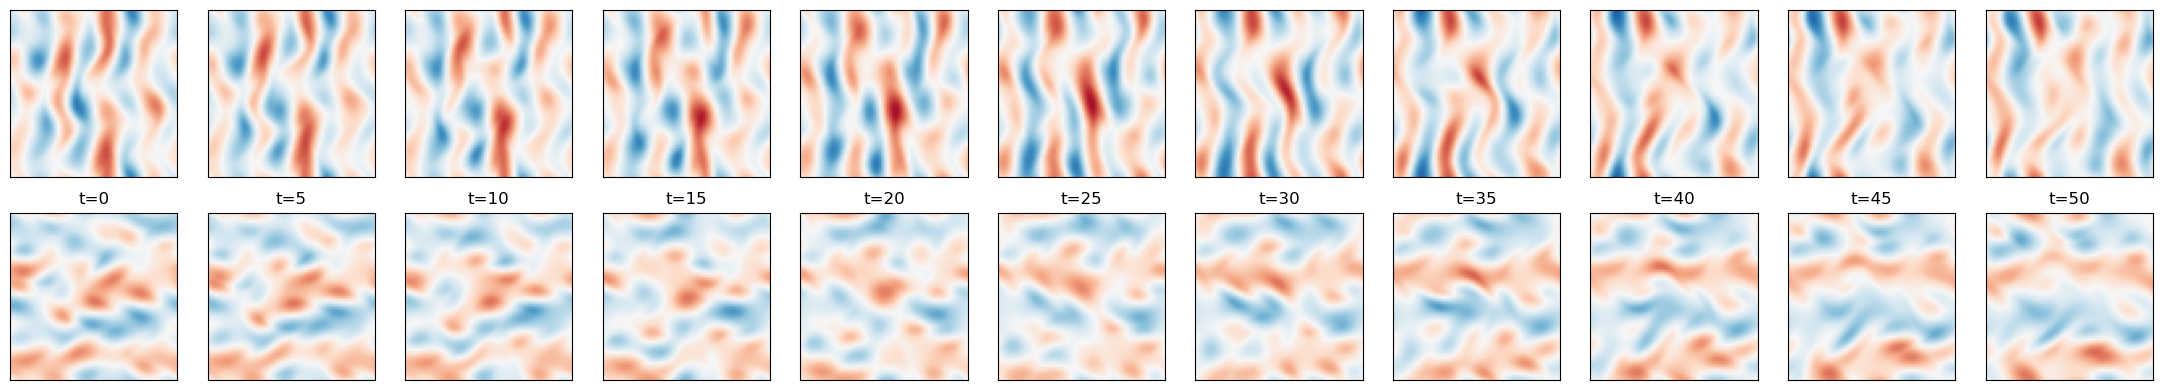

In [23]:
times = np.arange(0, 51, 5)
fig, ax = plt.subplots(2, len(times), figsize=(2*len(times), 4), layout='tight')
for ax_ in ax.flatten():
    ax_.set_xticks([])
    ax_.set_yticks([])
for j, t in enumerate(times):
    ax[0,j].imshow(test_data[0,t,0], cmap='RdBu', vmin=-3, vmax=3)
    ax[1,j].imshow(test_data[0,t,1], cmap='RdBu', vmin=-3, vmax=3)
for j, t in enumerate(times):
    ax[1,j].set_title(f't={t}')

In [24]:
def build_tf_dataset(
    data: np.ndarray,          # (N, T, 2, H, W)
    batch_size: int = 4,
    shuffle: bool = True,
    normalize: bool = True,
    mean: float = None,
    std: float = None,
):
    """Build a tf.data.Dataset of (input, target) one-step pairs.

    Each trajectory (T steps) contributes T-1 pairs:
        input  = state at t
        target = state at t+1

    Data layout is converted from (N, T, C, H, W)  [APEBench]
    to (B, H, W, C)  [our TF model].

    Returns
    -------
    dataset : tf.data.Dataset of ((B, H, W, C), (B, H, W, C))
    mean, std : floats used for normalisation
    """
    N, T, C, H, W = data.shape

    # Flatten trajectories into one-step pairs
    inp  = data[:, :-1].reshape(-1, C, H, W)   # (N*(T-1), C, H, W)
    tgt  = data[:, 1:].reshape(-1, C, H, W)

    # (N*(T-1), C, H, W) → (N*(T-1), H, W, C)
    inp = inp.transpose(0, 2, 3, 1).astype(np.float32)
    tgt = tgt.transpose(0, 2, 3, 1).astype(np.float32)

    if normalize:
        if mean is None:
            mean = float(inp.mean())
            std  = float(inp.std()) + 1e-8
        inp = (inp - mean) / std
        tgt = (tgt - mean) / std

    ds = tf.data.Dataset.from_tensor_slices((inp, tgt))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(inp), reshuffle_each_iteration=True)
    ds = ds.batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    return ds, mean, std

In [25]:
train_ds, mean, std = build_tf_dataset(
    train_data, batch_size=4, shuffle=True
)

In [26]:
test_ds, _, _ = build_tf_dataset(
    test_data, batch_size=4, shuffle=False,
    mean=mean, std=std
)

In [27]:
print(f"Normalisation: mean={mean:.4f}  std={std:.4f}")
print(f"Train batches / epoch: {len(train_ds)}")

Normalisation: mean=-0.0000  std=0.6876
Train batches / epoch: 625


# Set up model

In [28]:
in_channels  = 2     # (u, v)
out_channels = 2

model = PDETransformerSC(
    in_channels=in_channels,
    out_channels=out_channels,
    patch_size=4,
    embed_dim=64,
    depths=(2, 2, 4),
    num_heads=(2, 4, 8),
    window_size=4,
    cond_dim=128,
)

# Warm up the model to build weights
dummy = tf.zeros([1, 64, 64, in_channels])
_ = model(dummy)
total_params = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"\nModel parameters: {total_params:,}")

c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'conditioning_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\layer.py:970: UserWarning: Layer 'window_attention_11' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\layer.py:970: UserWarning: Layer 'window_attention_13' (of type WindowAttention) was passed an input with a mask attached to it. However, t


Model parameters: 996,924


In [29]:
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup then cosine decay to lr_min."""

    def __init__(self, peak_lr, warmup_steps, total_steps, lr_min=1e-6):
        super().__init__()
        self.peak_lr = peak_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.lr_min = lr_min

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = self.peak_lr * step / max(1, self.warmup_steps)
        cosine_decay = self.lr_min + 0.5 * (self.peak_lr - self.lr_min) * (
            1 + tf.cos(math.pi * (step - self.warmup_steps)
                       / max(1, self.total_steps - self.warmup_steps))
        )
        return tf.where(step < self.warmup_steps, warmup, cosine_decay)

    def get_config(self):
        return dict(
            peak_lr=self.peak_lr,
            warmup_steps=self.warmup_steps,
            total_steps=self.total_steps,
            lr_min=self.lr_min,
        )

In [30]:
steps_per_epoch = len(train_ds)
total_steps     = steps_per_epoch * 100
warmup_steps    = steps_per_epoch * max(1, 100 // 10)

lr_schedule = WarmupCosineDecay(
    peak_lr=5e-4,
    warmup_steps=warmup_steps,
    total_steps=total_steps,
)
optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-2,
)

# Train

In [31]:
@tf.function
def train_step(model, optimizer, x, y):
    with tf.GradientTape() as tape:
        pred = model(x, training=True)
        loss = tf.reduce_mean(tf.square(pred - y))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

In [32]:
def nrmse_rollout(model, test_data, mean, std, rollout_steps=20):
    """Multi-step rollout normalised RMSE (the APEBench metric).

    nRMSE at step k = ||ŷ_k − y_k||_F / ||y_k||_F
    averaged over all test trajectories.

    Returns array of length rollout_steps.
    """
    N, T, C, H, W = test_data.shape
    rollout_steps = min(rollout_steps, T - 1)

    nrmse = np.zeros(rollout_steps)
    n_traj = 0

    for traj in test_data:                      # (T, C, H, W)
        # initial condition (normalised), shape (1, H, W, C)
        x = ((traj[0].transpose(1, 2, 0) - mean) / std)[None].astype(np.float32)
        for k in range(rollout_steps):
            ref = ((traj[k + 1].transpose(1, 2, 0) - mean) / std)
            pred = model(x, training=False).numpy()[0]
            diff = pred - ref
            denom = np.linalg.norm(ref) + 1e-8
            nrmse[k] += np.linalg.norm(diff) / denom
            x = pred[None].astype(np.float32)
        n_traj += 1

    return nrmse / n_traj

In [ ]:
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "nrmse_1step": []}

print(f"\nTraining for {100} epochs …\n")
for epoch in range(1, 100 + 1):
    t0 = time.time()
    train_losses = []

    for x_batch, y_batch in train_ds:
        loss = train_step(model, optimizer, x_batch, y_batch)
        train_losses.append(float(loss))

    # Validation
    val_losses = []
    for x_batch, y_batch in test_ds:
        pred = model(x_batch, training=False)
        val_losses.append(float(tf.reduce_mean(tf.square(pred - y_batch))))

    train_loss = float(np.mean(train_losses))
    val_loss   = float(np.mean(val_losses))
    elapsed    = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    lr_now = float(lr_schedule(optimizer.iterations))
    print(f"Epoch {epoch:3d}/{100}  "
            f"train={train_loss:.5f}  val={val_loss:.5f}  "
            f"lr={lr_now:.2e}  [{elapsed:.1f}s]")

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_weights('./data/sc_kolm_flow_best.weights.h5')
        print(f"  ✓ checkpoint saved  (val={val_loss:.5f})")

    # Periodic rollout eval
    if epoch % 10 == 0 or epoch == 100:
        nrmse = nrmse_rollout(
            model, test_data, mean, std,
            rollout_steps=20
        )
        history["nrmse_1step"].append(float(nrmse[0]))
        print(f"  nRMSE rollout (first {len(nrmse)} steps): "
                + "  ".join(f"{v:.4f}" for v in nrmse))


Training for 100 epochs …

Epoch   1/100  train=0.59081  val=0.10199  lr=5.00e-05  [94.5s]
  ✓ checkpoint saved  (val=0.10199)
Epoch   2/100  train=0.04207  val=0.01507  lr=1.00e-04  [67.3s]
  ✓ checkpoint saved  (val=0.01507)
Epoch   3/100  train=0.01190  val=0.00796  lr=1.50e-04  [68.5s]
  ✓ checkpoint saved  (val=0.00796)
Epoch   4/100  train=0.00798  val=0.00719  lr=2.00e-04  [67.8s]
  ✓ checkpoint saved  (val=0.00719)
Epoch   5/100  train=0.00642  val=0.00488  lr=2.50e-04  [67.8s]
  ✓ checkpoint saved  (val=0.00488)
Epoch   6/100  train=0.00560  val=0.00435  lr=3.00e-04  [76.8s]
  ✓ checkpoint saved  (val=0.00435)
Epoch   7/100  train=0.00508  val=0.00407  lr=3.50e-04  [67.9s]
  ✓ checkpoint saved  (val=0.00407)
Epoch   8/100  train=0.00492  val=0.00375  lr=4.00e-04  [67.8s]
  ✓ checkpoint saved  (val=0.00375)
Epoch   9/100  train=0.00477  val=0.00377  lr=4.50e-04  [68.3s]
Epoch  10/100  train=0.00471  val=0.00378  lr=5.00e-04  [67.3s]
  nRMSE rollout (first 20 steps): 0.0618  0.

In [ ]:
print(f"Best val loss: {best_val_loss:.5f}")

Best val loss: 0.00149


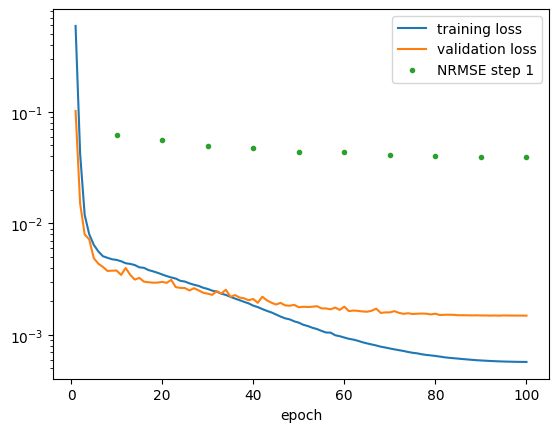

In [81]:
plt.yscale('log')
plt.plot(np.arange(1, 101, 1), history['train_loss'], label='training loss')
plt.plot(np.arange(1, 101, 1), history['val_loss'], label='validation loss')
plt.plot(np.arange(10, 110, 10), history['nrmse_1step'], '.', label='NRMSE step 1')
plt.legend()
plt.xlabel('epoch');

# Analyze

In [33]:
model.load_weights('./data/sc_kolm_flow_best.weights.h5')
nrmse_final = nrmse_rollout(
    model, test_data, mean, std, rollout_steps=20
)
print(f"Final nRMSE rollout ({20} steps):")
for k, v in enumerate(nrmse_final, start=1):
    print(f"  step {k:3d}: {v:.4f}")

Final nRMSE rollout (20 steps):
  step   1: 0.0417
  step   2: 0.0829
  step   3: 0.1245
  step   4: 0.1669
  step   5: 0.2098
  step   6: 0.2532
  step   7: 0.2967
  step   8: 0.3403
  step   9: 0.3839
  step  10: 0.4273
  step  11: 0.4700
  step  12: 0.5117
  step  13: 0.5530
  step  14: 0.5934
  step  15: 0.6325
  step  16: 0.6699
  step  17: 0.7052
  step  18: 0.7384
  step  19: 0.7699
  step  20: 0.7997


In [36]:
def vel_to_vorticity(u, v):
    """Compute vorticity ω = ∂v/∂x − ∂u/∂y via spectral differentiation.

    Args:
        u, v : (..., H, W) numpy arrays
    Returns:
        omega : (..., H, W) numpy array
    """
    H, W = u.shape[-2], u.shape[-1]
    kx = jnp.fft.fftfreq(H, d=1.0 / H)[:, None]     # (H, 1)
    ky = jnp.fft.rfftfreq(W, d=1.0 / W)[None, :]    # (1, W//2+1)

    u_f = jnp.fft.rfft2(jnp.array(u))
    v_f = jnp.fft.rfft2(jnp.array(v))

    # ω = ∂v/∂x − ∂u/∂y  →  î·kx·v̂ − î·ky·û  in Fourier space
    omega_f = 1j * kx * v_f - 1j * ky * u_f
    return np.array(jnp.fft.irfft2(omega_f, s=(H, W)))


def rollout(model, ic, num_steps, mean, std):
    """Autoregressive rollout from initial condition.

    Args:
        model    : PDETransformerSC
        ic       : (H, W, C) normalised numpy array — initial condition
        num_steps: int
        mean, std: normalisation scalars

    Returns:
        pred_traj : (num_steps+1, H, W, C) numpy array  (normalised)
    """
    states = [ic]
    x = ic[None].astype(np.float32)          # (1, H, W, C)
    for _ in range(num_steps):
        x = model(x, training=False).numpy()
        states.append(x[0])
    return np.stack(states, axis=0)          # (T, H, W, C)


def unnorm(arr, mean, std):
    return arr * std + mean


# ============================================================================
# Plot 1 — Rollout comparison grid
# ============================================================================

def plot_rollout_grid(
    gt_traj,          # (T, H, W, 2)  ground truth, physical units
    pred_traj,        # (T, H, W, 2)  prediction,  physical units
    vis_steps,        # which time step indices to show
    channel_names=("u", "v"),
    save_path="rollout_grid.png",
):
    """Side-by-side: GT | Prediction | |Error| for each channel × time step."""
    n_steps  = len(vis_steps)
    n_chan   = len(channel_names)
    n_rows   = n_chan * 3    # GT / Pred / Error per channel
    n_cols   = n_steps

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.6 * n_cols, 2.2 * n_rows),
        squeeze=False,
    )
    fig.suptitle("Velocity: truth, prediction, |error|", fontsize=13, y=1.01)

    for ci, cname in enumerate(channel_names):
        row_base = ci * 3
        # Shared colour scale across all time steps for this channel
        vmax = max(
            np.abs(gt_traj[vis_steps, :, :, ci]).max(),
            np.abs(pred_traj[vis_steps, :, :, ci]).max(),
        ) * 1.05
        norm_field = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        err_vmax   = np.abs(gt_traj[vis_steps, :, :, ci]
                            - pred_traj[vis_steps, :, :, ci]).max() * 1.05

        for col, t in enumerate(vis_steps):
            gt   = gt_traj[t, :, :, ci]
            pred = pred_traj[t, :, :, ci]
            err  = np.abs(gt - pred)

            kw = dict(origin="lower", aspect="equal", interpolation="bilinear")

            ax_gt   = axes[row_base,     col]
            ax_pred = axes[row_base + 1, col]
            ax_err  = axes[row_base + 2, col]

            im_gt   = ax_gt.imshow(gt,   cmap="RdBu_r", norm=norm_field, **kw)
            im_pred = ax_pred.imshow(pred, cmap="RdBu_r", norm=norm_field, **kw)
            im_err  = ax_err.imshow(err,  cmap="Reds",
                                    vmin=0, vmax=err_vmax, **kw)

            for ax in (ax_gt, ax_pred, ax_err):
                ax.set_xticks([])
                ax.set_yticks([])

            if col == 0:
                ax_gt.set_ylabel(f"{cname}  true",   fontsize=9)
                ax_pred.set_ylabel(f"{cname}  pred", fontsize=9)
                ax_err.set_ylabel(f"{cname}  |error|", fontsize=9)

            if row_base == 0:
                ax_gt.set_title(f"t={t}", fontsize=9)

        # Colourbar for field and error
        # fig.colorbar(im_gt,   ax=axes[row_base,     :], shrink=0.7,
        #              label=f"{cname} (physical)")
        # fig.colorbar(im_pred, ax=axes[row_base + 1, :], shrink=0.7)
        # fig.colorbar(im_err,  ax=axes[row_base + 2, :], shrink=0.7,
        #              label="|error|")

    plt.tight_layout()
    # plt.savefig(save_path, dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"  Saved: {save_path}")


# ============================================================================
# Plot 2 — nRMSE rollout curve
# ============================================================================

def plot_nrmse_curve(
    model,
    test_data,       # (N, T, 2, H, W) physical-unit velocity
    mean, std,
    rollout_steps=40,
    save_path="nrmse_rollout.png",
):
    """Plot autoregressive nRMSE per step for every test trajectory."""
    N, T = test_data.shape[:2]
    steps = min(rollout_steps, T - 1)
    all_nrmse = np.zeros((N, steps))

    for i, traj in enumerate(test_data):                   # (T, 2, H, W)
        # normalise and transpose to (H, W, C)
        ic_norm = ((traj[0].transpose(1, 2, 0) - mean) / std).astype(np.float32)
        pred_norm = rollout(model, ic_norm, steps, mean, std)   # (T, H, W, C)

        for k in range(steps):
            ref  = (traj[k + 1].transpose(1, 2, 0) - mean) / std
            pred = pred_norm[k + 1]
            denom = np.linalg.norm(ref) + 1e-8
            all_nrmse[i, k] = np.linalg.norm(pred - ref) / denom

    mean_nrmse = all_nrmse.mean(axis=0)
    step_axis  = np.arange(1, steps + 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(N):
        ax.plot(step_axis, all_nrmse[i], color="steelblue", alpha=0.3,
                linewidth=0.8, label="_nolegend_")
    ax.plot(step_axis, mean_nrmse, color="navy", linewidth=2, label="Mean nRMSE")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="nRMSE = 1 (trivial)")
    ax.set_xlabel("Rollout step")
    ax.set_ylabel("nRMSE")
    ax.set_title("Autoregressive rollout error (APEBench metric)")
    ax.legend()
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(save_path, dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"  Saved: {save_path}")
    return all_nrmse


# ============================================================================
# Plot 3 — Vorticity comparison
# ============================================================================

def plot_vorticity_grid(
    gt_traj,          # (T, H, W, 2)  ground truth velocity, physical units
    pred_traj,        # (T, H, W, 2)  predicted velocity, physical units
    vis_steps,
    save_path="vorticity_grid.png",
):
    """Vorticity ω = ∂v/∂x − ∂u/∂y: GT | Pred | |Error|."""
    n_cols = len(vis_steps)
    fig, axes = plt.subplots(3, n_cols, figsize=(2.6 * n_cols, 6.6), squeeze=False)
    fig.suptitle("Vorticity: truth, prediction, |error|", fontsize=13, y=1.01)

    gt_omega   = vel_to_vorticity(gt_traj[..., 0],   gt_traj[..., 1])    # (T,H,W)
    pred_omega = vel_to_vorticity(pred_traj[..., 0], pred_traj[..., 1])

    vmax     = np.abs(gt_omega[vis_steps]).max() * 1.05
    err_vmax = np.abs(gt_omega[vis_steps] - pred_omega[vis_steps]).max() * 1.05
    norm     = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    row_labels = ["true ω", "pred ω", "|error| ω"]
    for col, t in enumerate(vis_steps):
        kw = dict(origin="lower", aspect="equal", interpolation="bilinear")
        im0 = axes[0, col].imshow(gt_omega[t],   cmap="RdBu_r", norm=norm, **kw)
        im1 = axes[1, col].imshow(pred_omega[t], cmap="RdBu_r", norm=norm, **kw)
        im2 = axes[2, col].imshow(
            np.abs(gt_omega[t] - pred_omega[t]),
            cmap="Reds", vmin=0, vmax=err_vmax, **kw
        )
        for row, ax in enumerate(axes[:, col]):
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=9)
        axes[0, col].set_title(f"t={t}", fontsize=9)

    # fig.colorbar(im0, ax=axes[:2, :], shrink=0.6, label="ω (1/s)")
    # fig.colorbar(im2, ax=axes[2,  :], shrink=0.6, label="|error|")
    plt.tight_layout()
    # plt.savefig(save_path, dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"  Saved: {save_path}")

In [35]:
traj_phys = test_data[0]  # (T, 2, H, W) physical units
ic_norm   = ((traj_phys[0].transpose(1, 2, 0) - mean) / std).astype(np.float32)

steps = min(40, test_data.shape[1] - 1)
print(f"Running {steps}-step rollout on test trajectory {0}")
pred_norm = rollout(model, ic_norm, steps, mean, std)  # (steps+1, H, W, C)

# Convert to physical units: (T, H, W, 2) -> keep only the steps we have GT for
T_vis    = steps + 1
gt_hwc   = traj_phys[:T_vis].transpose(0, 2, 3, 1)  # (T, H, W, 2)
pred_hwc = unnorm(pred_norm[:T_vis], mean, std)  # (T, H, W, 2)

# Choose time step indices to display in grid
vis_steps = np.linspace(0, T_vis - 1, min(6, T_vis), dtype=int).tolist()
print(f"Visualising steps: {vis_steps}")

Running 40-step rollout on test trajectory 0
Visualising steps: [0, 8, 16, 24, 32, 40]


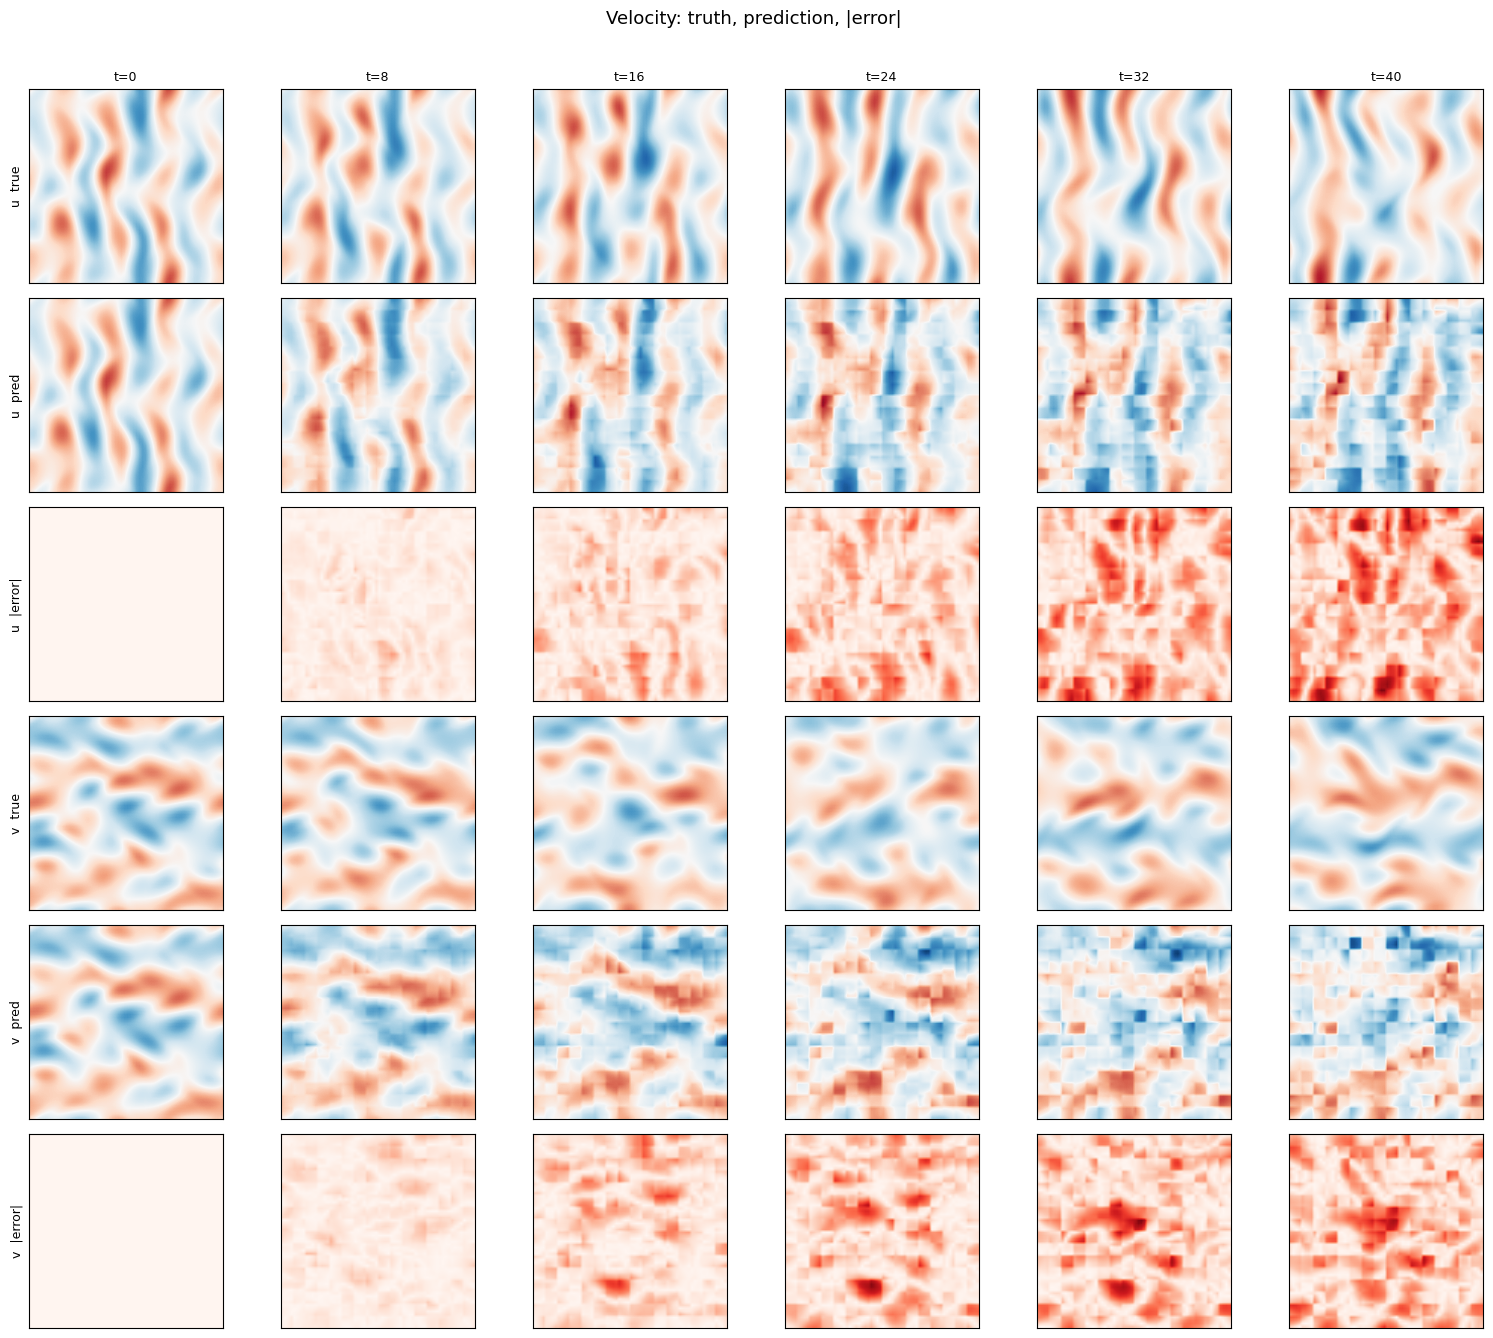

In [37]:
plot_rollout_grid(
    gt_hwc, pred_hwc, vis_steps,
    # save_path="./images/rollout_grid_traj0.png",
)

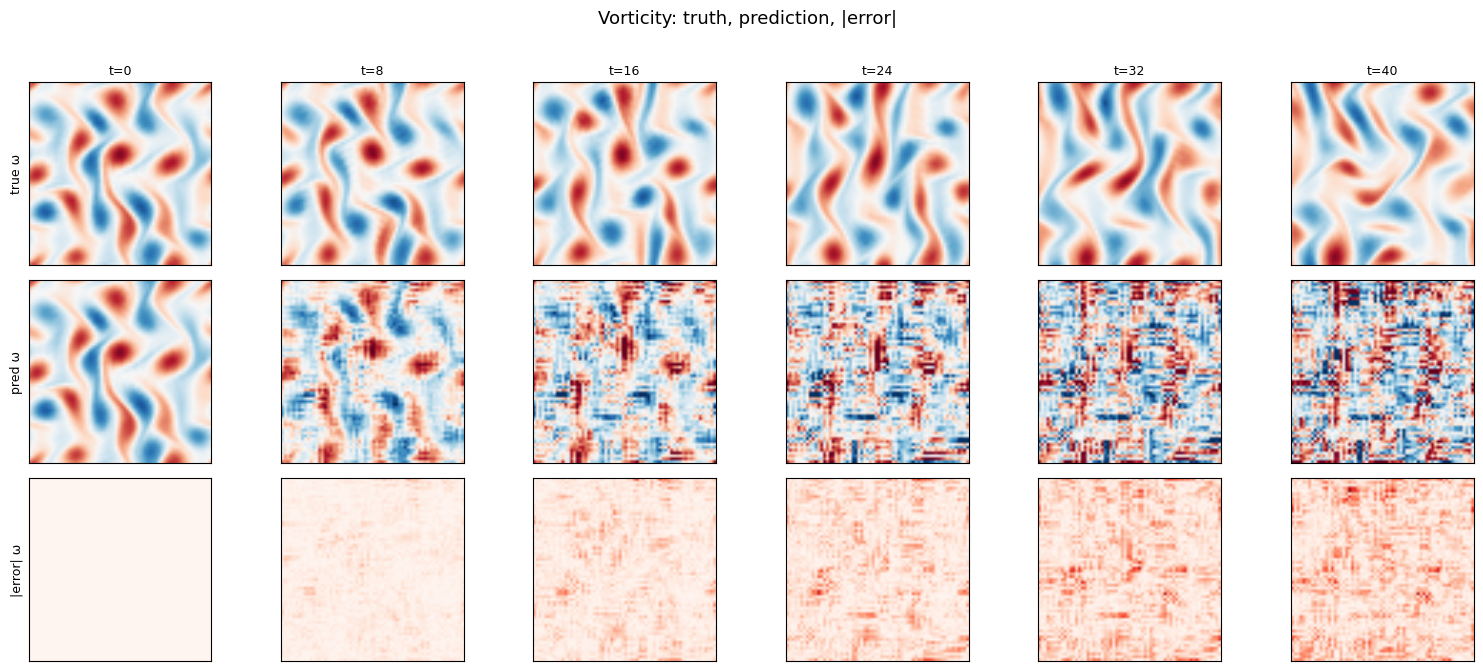

In [38]:
plot_vorticity_grid(
    gt_hwc, pred_hwc, vis_steps,
    # save_path="./images/vorticity_grid_traj0.png",
)

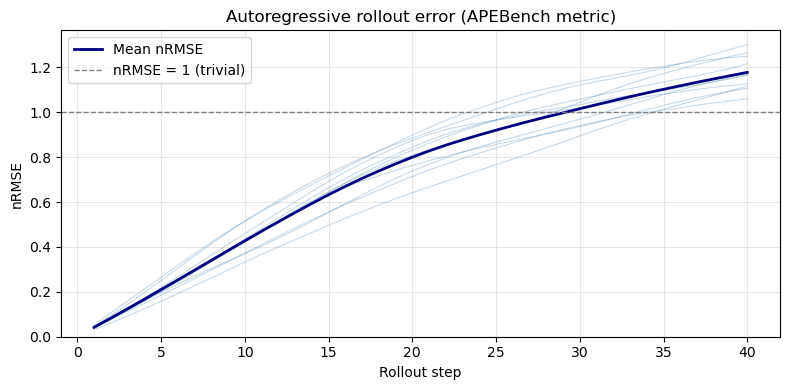

In [39]:
nrmse = plot_nrmse_curve(
    model, test_data, mean, std,
    rollout_steps=steps,
    # save_path="./images/nrmse_rollout.png"),
)